In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import glob
import re

plt.rcParams.update({
    "text.usetex": False})
plt.rcParams['svg.fonttype'] = 'none'
plt.rc('pdf',fonttype = 42)
plt.rcParams["ps.useafm"] = True

plt.rcParams['axes.grid'] = False
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.bottom'] = True
plt.rcParams.update({'font.size': 10})

plt.rcParams["legend.frameon"] = False

In [3]:
def parse_data(target_loop_idx, params, 
               type_to_report = 'inner', 
               report_params=['volume_density'],
              metric='obs'):
    master_data = []
    ftags=[]

    for i, row in params.iterrows():
        f = os.path.join(basedir, params.loc[i, 'result_file'])
        basename = os.path.basename(f).replace('.tsv', '')
        row_dict = {}

        df = pd.read_csv(f, sep='\t')
        #print(df)
        if type_to_report == 'inner':
            loop_row = df[df['MM'] == 'inner'].iloc[target_loop_idx]
            if i == 0:
                print(df[df['MM'] == 'inner'])
        elif type_to_report == 'EP':
            loop_row = df[df['loop_type'] == 'EP'].iloc[target_loop_idx]
        elif type_to_report == 'outer':
            loop_row = df[df['MM'] == 'outer'].iloc[target_loop_idx]
            if i == 0:
                print(df[df['MM'] == 'outer'])
        elif type_to_report == 'CTCF_conv':
            loop_row = df[df['loop_type'] == 'CTCF_conv'].iloc[target_loop_idx]
            if pd.notna(loop_row['MM']):
                print("Warning: it's a MM loop")
        elif type_to_report == 'CTCF_other':
            loop_row = df[df['loop_type'] == 'CTCF_other'].iloc[target_loop_idx]
        row_dict['mean'] = loop_row[f'{metric}_mean']
        row_dict['se'] = loop_row[f'{metric}_se']
        master_data.append(row_dict)
        
        param_string=""
        for k in range(len(report_params)):
            param_string = f"{param_string}{params.loc[i, report_params[k]]}_"
        ftags.append(param_string)
    print(loop_row.left, loop_row.right)
    master_df = pd.DataFrame(master_data)
    master_df.index = ftags    
    
    return master_df, ftags


# def error_propagate_se(df, idx_control):
#     error_sq = (master_df['se']/master_df['mean'])**2
#     const_err = (master_df['se'].loc[idx_control]/master_df['mean'].loc[idx_control])**2
#     print(const_err)
#     fc_se = np.sqrt(error_sq.values + const_err)
    
#     return fc_se

def error_propagate_se(df, idx_control):
    error_sq = (master_df['se']/master_df['mean'])**2
    const_err = (master_df['se'].iloc[idx_control]/master_df['mean'].iloc[idx_control])**2
    fc_se = np.sqrt(error_sq.values + const_err)
    
    return fc_se

In [4]:
basedir = "/mnt/md1/varshini/Blood/sim_density_processed_v2"
params = pd.read_csv(os.path.join(basedir, "mapping.tsv"), sep="\t").replace(np.nan, 0)
params['volume_density'] =params['volume_density'].replace(0, 0.3)
params = params[params['run_id']!='run_000'] # uncorrected density


In [5]:
#select = params[params['vel_steps']=='(0.0025, 50)']
#select = select[~select["original_path"].str.contains("/mnt/md1/varshini/Blood/sim_data_velocity/2026-04-26 17:37:59.846865")]

In [6]:
params

,run_id,sim_id,original_path,result_file,parameters_file,processivity,separations,ctcf_boost_factor,llp,h,loading_width,cohesins_per_mm,volume_density,vel_steps
2,run_002,sim_00,/mnt/md1/varshini/Blood/sim_data_density/2026-...,run_002_sim_00_loops.tsv,run_002_sim_00_parameters.txt,300,240,4,2,0.4,16,64.0,0.15,"(0.0025, 50)"
3,run_002,sim_01,/mnt/md1/varshini/Blood/sim_data_density/2026-...,run_002_sim_01_loops.tsv,run_002_sim_01_parameters.txt,300,240,4,2,0.4,16,64.0,0.45,"(0.0025, 50)"
4,run_002,sim_02,/mnt/md1/varshini/Blood/sim_data_density/2026-...,run_002_sim_02_loops.tsv,run_002_sim_02_parameters.txt,300,240,4,2,0.4,16,64.0,0.60,"(0.0025, 50)"
5,run_003,sim_00,/mnt/md1/varshini/Blood/sim_data_density/2026-...,run_003_sim_00_loops.tsv,run_003_sim_00_parameters.txt,300,240,4,2,0.4,16,0.0,0.60,"(0.0025, 50)"
6,run_004,sim_00,/mnt/md1/varshini/Blood/sim_data_density/2026-...,run_004_sim_00_loops.tsv,run_004_sim_00_parameters.txt,300,240,4,2,0.4,2,256.0,0.30,"(0.0025, 50)"
7,run_007,sim_00,/mnt/md1/varshini/Blood/sim_data_density/orig_...,run_007_sim_00_loops.tsv,run_007_sim_00_parameters.txt,300,240,4,2,0.4,16,32.0,0.30,"(0.0025, 50)"
8,run_007,sim_01,/mnt/md1/varshini/Blood/sim_data_density/orig_...,run_007_sim_01_loops.tsv,run_007_sim_01_parameters.txt,300,240,4,2,0.4,32,32.0,0.30,"(0.0025, 50)"
9,run_007,sim_02,/mnt/md1/varshini/Blood/sim_data_density/orig_...,run_007_sim_02_loops.tsv,run_007_sim_02_parameters.txt,300,240,4,2,0.4,4,32.0,0.30,"(0.0025, 50)"
10,run_007,sim_03,/mnt/md1/varshini/Blood/sim_data_density/orig_...,run_007_sim_03_loops.tsv,run_007_sim_03_parameters.txt,300,240,4,2,0.4,8,32.0,0.30,"(0.0025, 50)"
11,run_007,sim_04,/mnt/md1/varshini/Blood/sim_data_density/orig_...,run_007_sim_04_loops.tsv,run_007_sim_04_parameters.txt,300,240,4,2,0.4,16,64.0,0.30,"(0.0025, 50)"


In [7]:
savedir="/mnt/md0/varshini/Analysis/Blood/figs_v2/sim_loop_strengths/"

In [8]:
select = params[((params['cohesins_per_mm']==64) | (params['cohesins_per_mm']==0) | (params['cohesins_per_mm']==256)) 
                & (params['volume_density']==0.3)]


In [9]:
select

,run_id,sim_id,original_path,result_file,parameters_file,processivity,separations,ctcf_boost_factor,llp,h,loading_width,cohesins_per_mm,volume_density,vel_steps
6,run_004,sim_00,/mnt/md1/varshini/Blood/sim_data_density/2026-...,run_004_sim_00_loops.tsv,run_004_sim_00_parameters.txt,300,240,4,2,0.4,2,256.0,0.3,"(0.0025, 50)"
11,run_007,sim_04,/mnt/md1/varshini/Blood/sim_data_density/orig_...,run_007_sim_04_loops.tsv,run_007_sim_04_parameters.txt,300,240,4,2,0.4,16,64.0,0.3,"(0.0025, 50)"
12,run_007,sim_05,/mnt/md1/varshini/Blood/sim_data_density/orig_...,run_007_sim_05_loops.tsv,run_007_sim_05_parameters.txt,300,240,4,2,0.4,32,64.0,0.3,"(0.0025, 50)"
13,run_007,sim_06,/mnt/md1/varshini/Blood/sim_data_density/orig_...,run_007_sim_06_loops.tsv,run_007_sim_06_parameters.txt,300,240,4,2,0.4,4,64.0,0.3,"(0.0025, 50)"
14,run_007,sim_07,/mnt/md1/varshini/Blood/sim_data_density/orig_...,run_007_sim_07_loops.tsv,run_007_sim_07_parameters.txt,300,240,4,2,0.4,8,64.0,0.3,"(0.0025, 50)"
15,run_007,sim_08,/mnt/md1/varshini/Blood/sim_data_density/orig_...,run_007_sim_08_loops.tsv,run_007_sim_08_parameters.txt,300,240,4,2,0.4,4,0.0,0.3,"(0.0025, 50)"


330 574


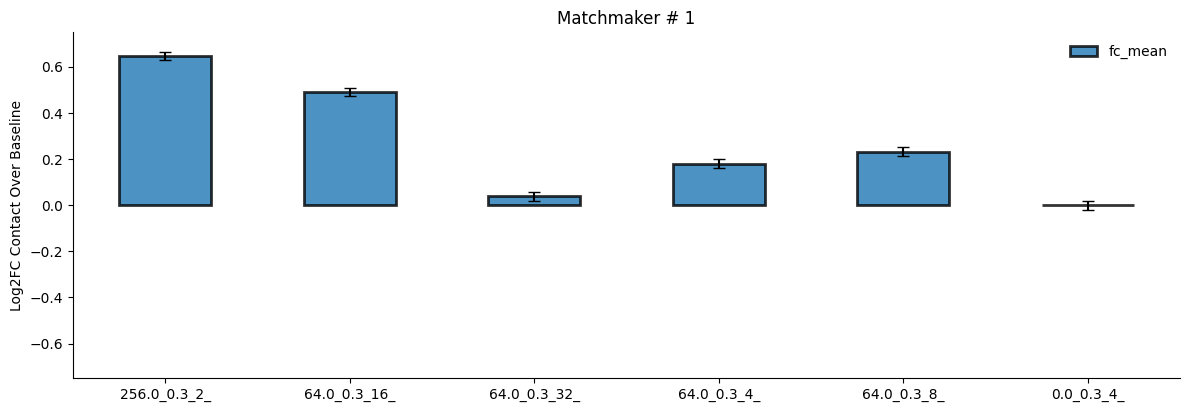

In [10]:
# inner 
order = select.reset_index().index
for idx in [0]:
    master_df, ftags = parse_data(idx, select, type_to_report='inner', 
                                  report_params=["cohesins_per_mm", "volume_density", "loading_width"],
                                 metric='obs')

    idx_control=-1

    master_df['fc_mean']=np.log2(master_df['mean']/master_df['mean'].iloc[idx_control])
    master_df['propagated_se']=error_propagate_se(master_df, idx_control=idx_control)
    master_df.iloc[order, :].plot(
            kind='bar',
            y='fc_mean',
            yerr='propagated_se', 
            capsize=4, 
            edgecolor='black',
            alpha=0.8,
            linewidth=2,
        figsize=(12, 4)
        )

    # Rotate x-labels if they are squished
    plt.xticks(rotation=0)
    plt.ylabel('Log2FC Contact Over Baseline')
    plt.ylim([-0.75, 0.75])
    plt.tight_layout()
    
    plt.title(f"Matchmaker # {idx + 1}")
    #plt.savefig(os.path.join(savedir, f"inner_loop{idx}_loading.svg"))
    
    plt.show()


In [11]:
master_df

,mean,se,fc_mean,propagated_se
256.0_0.3_2_,0.154587,0.001704,0.646136,0.017780
64.0_0.3_16_,0.138774,0.001711,0.490452,0.018620
64.0_0.3_32_,0.101434,0.001561,0.038255,0.020775
64.0_0.3_4_,0.111822,0.001480,0.178919,0.019234
64.0_0.3_8_,0.115946,0.001653,0.231171,0.019947
0.0_0.3_4_,0.098780,0.001378,0.000000,0.019730


200 694


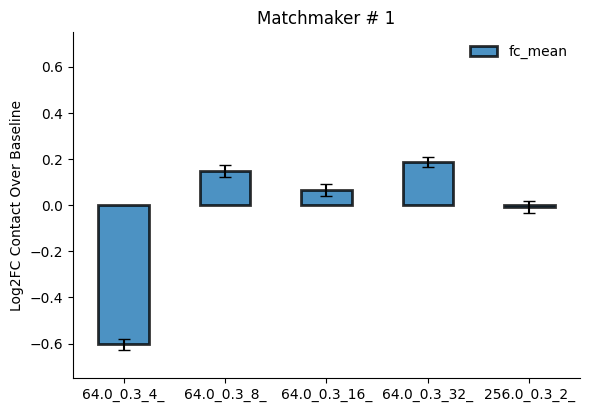

In [12]:
idx = 0
master_df, ftags = parse_data(idx, select, type_to_report='outer', 
                              report_params=["cohesins_per_mm", "volume_density", "loading_width"],
                             metric='obs')

idx_control=-1
order = [3, 4, 1, 2, 0]

master_df['fc_mean']=np.log2(master_df['mean']/master_df['mean'].iloc[idx_control])
master_df['propagated_se']=error_propagate_se(master_df, idx_control=idx_control)
master_df.iloc[order, :].plot(
        kind='bar',
        y='fc_mean',
        yerr='propagated_se', 
        capsize=4, 
        edgecolor='black',
        alpha=0.8,
        linewidth=2,
    figsize=(6, 4)
    )
    
# Rotate x-labels if they are squished
plt.xticks(rotation=0)
plt.ylabel('Log2FC Contact Over Baseline')
plt.ylim([-0.75, 0.75])
plt.tight_layout()
plt.title(f"Matchmaker # {idx + 1}")
#plt.savefig(os.path.join(savedir, f"outer_loop{idx}_loading.svg"))
plt.show()

330 574


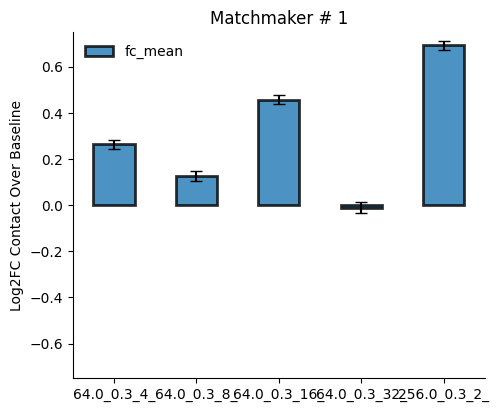

In [13]:
idx = 0
master_df, ftags = parse_data(idx, select, type_to_report='inner', 
                              report_params=["cohesins_per_mm", "volume_density", "loading_width"],
                             metric='oe')

idx_control=-1

master_df['fc_mean']=np.log2(master_df['mean']/master_df['mean'].iloc[idx_control])
master_df['propagated_se']=error_propagate_se(master_df, idx_control=idx_control)
master_df.iloc[order, :].plot(
        kind='bar',
        y='fc_mean',
        yerr='propagated_se', 
        capsize=4, 
        edgecolor='black',
        alpha=0.8,
        linewidth=2,
    figsize=(5, 4)
    )
    
# Rotate x-labels if they are squished
plt.xticks(rotation=0)
plt.ylabel('Log2FC Contact Over Baseline')
#plt.ylim([0, 0.25])
plt.tight_layout()
#plt.savefig(os.path.join(savedir, f"loop_{loop_idx}_fc.svg"))
plt.title(f"Matchmaker # {idx + 1}")
plt.ylim([-0.75, 0.75])
#plt.savefig(os.path.join(savedir, f"outer_loop{idx}_density.svg"))

plt.show()

In [14]:
select = params[((params['cohesins_per_mm']==64) & (params['loading_width']==16)) | 
                ((params['cohesins_per_mm']==0) & (params['loading_width']==4))]


330 574


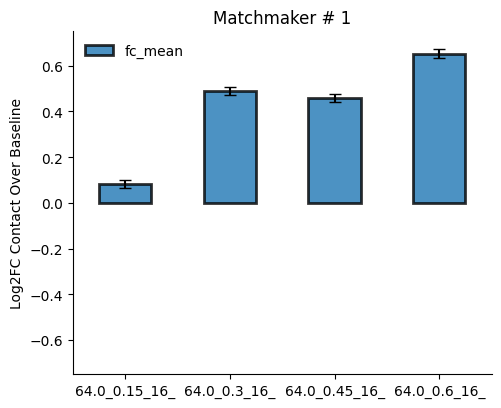

In [15]:
# inner: increased cohesin volume density 
order = [0, 3, 1, 2]
for idx in [0]:
    master_df, ftags = parse_data(idx, select, type_to_report='inner', 
                                  report_params=["cohesins_per_mm", "volume_density", "loading_width"],
                                 metric='obs')

    idx_control=-1

    master_df['fc_mean']=np.log2(master_df['mean']/master_df['mean'].iloc[idx_control])
    master_df['propagated_se']=error_propagate_se(master_df, idx_control=idx_control)
    master_df.iloc[order, :].plot(
            kind='bar',
            y='fc_mean',
            yerr='propagated_se', 
            capsize=4, 
            edgecolor='black',
            alpha=0.8,
            linewidth=2,
        figsize=(5, 4)
        )

    # Rotate x-labels if they are squished
    plt.xticks(rotation=0)
    plt.ylabel('Log2FC Contact Over Baseline')
    #plt.ylim([0, 0.25])
    plt.tight_layout()
    #
    plt.title(f"Matchmaker # {idx + 1}")
    plt.ylim([-0.75, 0.75])
    plt.savefig(os.path.join(savedir, f"inner_loop{idx}_density.svg"))
    plt.show()


250 540


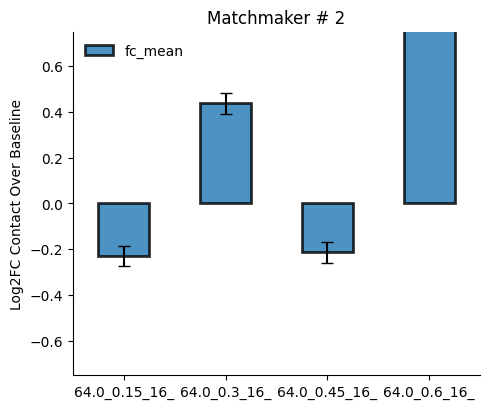

In [98]:
idx = 1
master_df, ftags = parse_data(idx, select, type_to_report='EP', 
                              report_params=["cohesins_per_mm", "volume_density", "loading_width"],
                             metric='obs')

idx_control=-1

master_df['fc_mean']=np.log2(master_df['mean']/master_df['mean'].iloc[idx_control])
master_df['propagated_se']=error_propagate_se(master_df, idx_control=idx_control)
master_df.iloc[order, :].plot(
        kind='bar',
        y='fc_mean',
        yerr='propagated_se', 
        capsize=4, 
        edgecolor='black',
        alpha=0.8,
        linewidth=2,
    figsize=(5, 4)
    )
    
# Rotate x-labels if they are squished
plt.xticks(rotation=0)
plt.ylabel('Log2FC Contact Over Baseline')
#plt.ylim([0, 0.25])
plt.tight_layout()
#plt.savefig(os.path.join(savedir, f"loop_{loop_idx}_fc.svg"))
plt.title(f"Matchmaker # {idx + 1}")
plt.ylim([-0.75, 0.75])
#plt.savefig(os.path.join(savedir, f"outer_loop{idx}_density.svg"))

plt.show()

200 694


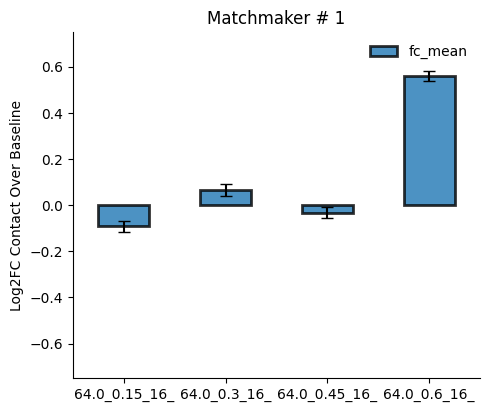

In [81]:
idx = 0
master_df, ftags = parse_data(idx, select, type_to_report='outer', 
                              report_params=["cohesins_per_mm", "volume_density", "loading_width"],
                             metric='obs')

idx_control=-1

master_df['fc_mean']=np.log2(master_df['mean']/master_df['mean'].iloc[idx_control])
master_df['propagated_se']=error_propagate_se(master_df, idx_control=idx_control)
master_df.iloc[order, :].plot(
        kind='bar',
        y='fc_mean',
        yerr='propagated_se', 
        capsize=4, 
        edgecolor='black',
        alpha=0.8,
        linewidth=2,
    figsize=(5, 4)
    )
    
# Rotate x-labels if they are squished
plt.xticks(rotation=0)
plt.ylabel('Log2FC Contact Over Baseline')
#plt.ylim([0, 0.25])
plt.tight_layout()
#plt.savefig(os.path.join(savedir, f"loop_{loop_idx}_fc.svg"))
plt.title(f"Matchmaker # {idx + 1}")
plt.ylim([-0.75, 0.75])
plt.savefig(os.path.join(savedir, f"outer_loop{idx}_density.svg"))

plt.show()

## Other targeted loading sites for supp 11

In [100]:
select = params[((params['cohesins_per_mm']==64) | (params['cohesins_per_mm']==0) | (params['cohesins_per_mm']==256)) 
                & (params['volume_density']==0.3)]


724 1241


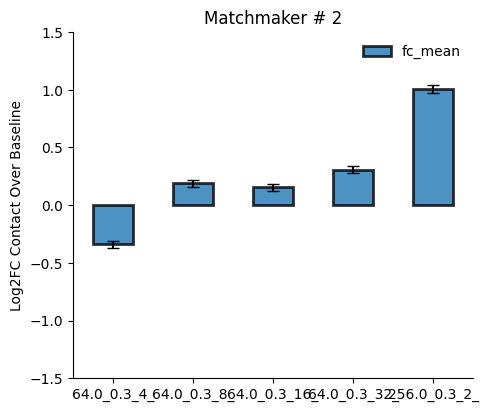

1433 1580


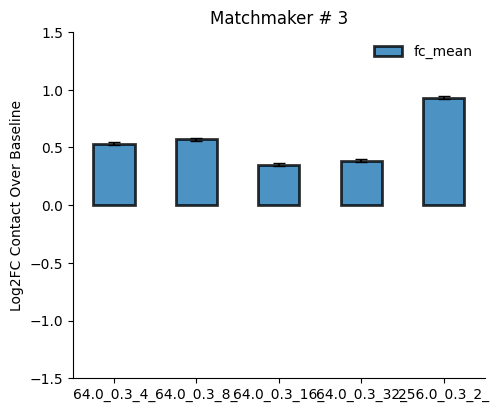

In [101]:
# inner: increased cohesin volume density 
order = [3, 4, 1, 2, 0]
for idx in [1,2]:
    master_df, ftags = parse_data(idx, select, type_to_report='inner', 
                                  report_params=["cohesins_per_mm", "volume_density", "loading_width"],
                                 metric='obs')

    idx_control=-1

    master_df['fc_mean']=np.log2(master_df['mean']/master_df['mean'].iloc[idx_control])
    master_df['propagated_se']=error_propagate_se(master_df, idx_control=idx_control)
    master_df.iloc[order, :].plot(
            kind='bar',
            y='fc_mean',
            yerr='propagated_se', 
            capsize=4, 
            edgecolor='black',
            alpha=0.8,
            linewidth=2,
        figsize=(5, 4)
        )

    # Rotate x-labels if they are squished
    plt.xticks(rotation=0)
    plt.ylabel('Log2FC Contact Over Baseline')
    #plt.ylim([0, 0.25])
    plt.tight_layout()
    #
    plt.title(f"Matchmaker # {idx + 1}")
    plt.ylim([-1.5, 1.5])
    plt.savefig(os.path.join(savedir, f"inner_loop{idx}_loading.svg"))
    plt.show()



1425 1752


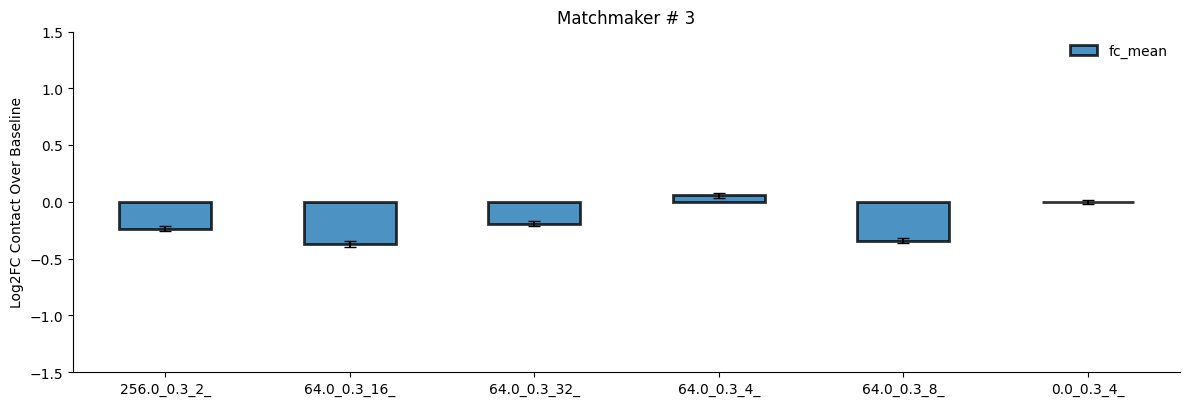

In [102]:
# outer 
order = select.reset_index().index
for idx in [2]:
    master_df, ftags = parse_data(idx, select, type_to_report='outer', 
                                  report_params=["cohesins_per_mm", "volume_density", "loading_width"],
                                 metric='obs')

    idx_control=-1

    master_df['fc_mean']=np.log2(master_df['mean']/master_df['mean'].iloc[idx_control])
    master_df['propagated_se']=error_propagate_se(master_df, idx_control=idx_control)
    master_df.iloc[order, :].plot(
            kind='bar',
            y='fc_mean',
            yerr='propagated_se', 
            capsize=4, 
            edgecolor='black',
            alpha=0.8,
            linewidth=2,
        figsize=(12, 4)
        )

    # Rotate x-labels if they are squished
    plt.xticks(rotation=0)
    plt.ylabel('Log2FC Contact Over Baseline')
    plt.ylim([-1.5, 1.5])
    plt.tight_layout()
    
    plt.title(f"Matchmaker # {idx + 1}")
    plt.savefig(os.path.join(savedir, f"outer_loop{idx}_loading.svg"))
    
    plt.show()

724 1390


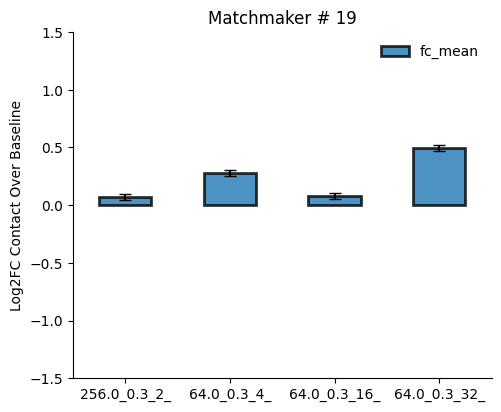

In [109]:
# inner: increased cohesin volume density 
order = [0, 3, 1, 2]
for idx in [18]:
    master_df, ftags = parse_data(idx, select, type_to_report='CTCF_conv', 
                                  report_params=["cohesins_per_mm", "volume_density", "loading_width"],
                                 metric='obs')

    idx_control=-1

    master_df['fc_mean']=np.log2(master_df['mean']/master_df['mean'].iloc[idx_control])
    master_df['propagated_se']=error_propagate_se(master_df, idx_control=idx_control)
    master_df.iloc[order, :].plot(
            kind='bar',
            y='fc_mean',
            yerr='propagated_se', 
            capsize=4, 
            edgecolor='black',
            alpha=0.8,
            linewidth=2,
        figsize=(5, 4)
        )

    # Rotate x-labels if they are squished
    plt.xticks(rotation=0)
    plt.ylabel('Log2FC Contact Over Baseline')
    #plt.ylim([0, 0.25])
    plt.tight_layout()
    #
    plt.title(f"Matchmaker # {idx + 1}")
    plt.ylim([-1.5, 1.5])
    #plt.savefig(os.path.join(savedir, f"inner_loop{idx}_density.svg"))
    plt.show()


In [104]:
# now density sweep

In [69]:
select = params[((params['cohesins_per_mm']==64) & (params['loading_width']==16)) | 
                ((params['cohesins_per_mm']==0) & (params['loading_width']==4))]


724 1241


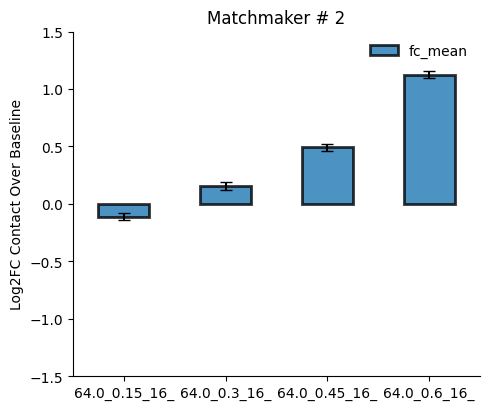

1433 1580


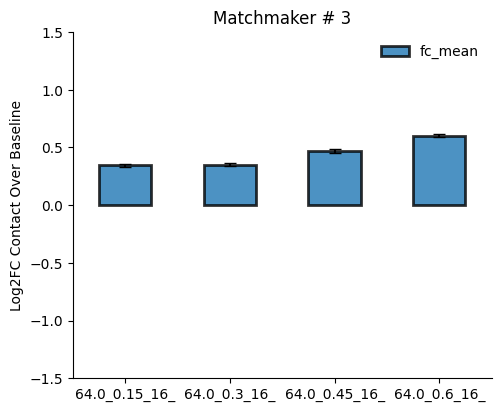

In [70]:
# inner: increased cohesin volume density 
order = [0, 3, 1, 2]
for idx in [1,2]:
    master_df, ftags = parse_data(idx, select, type_to_report='inner', 
                                  report_params=["cohesins_per_mm", "volume_density", "loading_width"],
                                 metric='obs')

    idx_control=-1

    master_df['fc_mean']=np.log2(master_df['mean']/master_df['mean'].iloc[idx_control])
    master_df['propagated_se']=error_propagate_se(master_df, idx_control=idx_control)
    master_df.iloc[order, :].plot(
            kind='bar',
            y='fc_mean',
            yerr='propagated_se', 
            capsize=4, 
            edgecolor='black',
            alpha=0.8,
            linewidth=2,
        figsize=(5, 4)
        )

    # Rotate x-labels if they are squished
    plt.xticks(rotation=0)
    plt.ylabel('Log2FC Contact Over Baseline')
    #plt.ylim([0, 0.25])
    plt.tight_layout()
    #
    plt.title(f"Matchmaker # {idx + 1}")
    plt.ylim([-1.5, 1.5])
    plt.savefig(os.path.join(savedir, f"inner_loop{idx}_density.svg"))
    plt.show()



866 1425


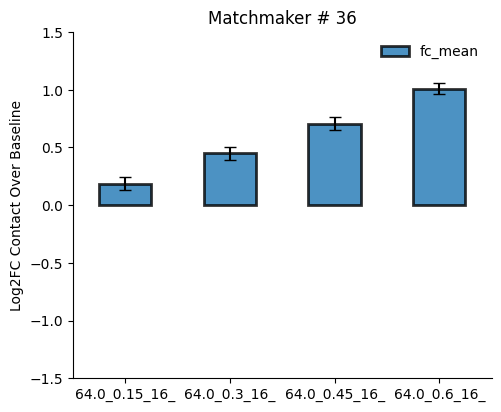

In [75]:
# inner: increased cohesin volume density 
order = [0, 3, 1, 2]
for idx in [35]:
    master_df, ftags = parse_data(idx, select, type_to_report='CTCF_other', 
                                  report_params=["cohesins_per_mm", "volume_density", "loading_width"],
                                 metric='obs')

    idx_control=-1

    master_df['fc_mean']=np.log2(master_df['mean']/master_df['mean'].iloc[idx_control])
    master_df['propagated_se']=error_propagate_se(master_df, idx_control=idx_control)
    master_df.iloc[order, :].plot(
            kind='bar',
            y='fc_mean',
            yerr='propagated_se', 
            capsize=4, 
            edgecolor='black',
            alpha=0.8,
            linewidth=2,
        figsize=(5, 4)
        )

    # Rotate x-labels if they are squished
    plt.xticks(rotation=0)
    plt.ylabel('Log2FC Contact Over Baseline')
    #plt.ylim([0, 0.25])
    plt.tight_layout()
    #
    plt.title(f"Matchmaker # {idx + 1}")
    plt.ylim([-1.5, 1.5])
    #plt.savefig(os.path.join(savedir, f"inner_loop{idx}_density.svg"))
    plt.show()
